# 03 -- Baselines

Мы решаем регрессию задержки в секундах. Метрика -- MAE, поэтому самые простые baseline -- константы и текущая известная задержка `cur_dev_s`.

`GaussianNB` сам по себе решает классификацию, а не регрессию. Для baseline я предсказываю `early / ontime / late`, затем перевожу вероятности классов в секунды через средний `target_delay_s` каждого класса на train.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

BL_SEED = 143
np.random.seed(BL_SEED)


## 1. Загрузка

Ноутбук не зависит от состояния `01` и `02`: он читает только исходные файлы. Поэтому его можно запускать параллельно с ними в том же kernel.

In [2]:
bl_point_dates = ['T', 'target_time_begin']

bl_train = pd.read_csv('../dataset/labels/labels_train.csv', parse_dates=bl_point_dates)
bl_test = pd.read_csv('../dataset/labels/labels_test.csv', parse_dates=bl_point_dates)
bl_validate = pd.read_csv('../dataset/validate/points.csv', parse_dates=bl_point_dates)
bl_submission_template = pd.read_csv('../dataset/sample_submission.csv', sep=';')

bl_train.shape, bl_test.shape, bl_validate.shape


((4434, 8), (353, 8), (151, 6))

## 2. Константные baseline

In [3]:
bl_train_mean = bl_train.target_delay_s.mean()
bl_train_median = bl_train.target_delay_s.median()

pd.Series({
    'train mean': bl_train_mean,
    'train median': bl_train_median,
    'test target mean': bl_test.target_delay_s.mean(),
    'test target median': bl_test.target_delay_s.median()
})


train mean            48.889716
train median          24.000000
test target mean      55.654391
test target median    26.000000
dtype: float64

In [4]:
bl_test_predictions = pd.DataFrame({
    'zero': np.zeros(len(bl_test)),
    'train_mean': np.full(len(bl_test), bl_train_mean),
    'train_median': np.full(len(bl_test), bl_train_median),
    'cur_dev': bl_test.cur_dev_s.to_numpy()
})


## 3. Gaussian Naive Bayes

Для совсем простого ML-baseline беру только признаки, которые уже лежат в прогнозной точке и точно известны к `T`: текущую задержку, горизонт прогноза и время суток. Добавляю signed-log текущей задержки, чтобы дать модели менее тяжелохвостое представление.

Это специально слабый baseline -- сложную телеметрию и признаки из `02` здесь не использую.

In [5]:
def bl_make_nb_features(points):
    x = pd.DataFrame(index=points.index)
    x['cur_dev_s'] = points.cur_dev_s
    x['cur_dev_signed_log'] = np.sign(points.cur_dev_s) * np.log1p(np.abs(points.cur_dev_s))
    x['horizon_min'] = (
        points.target_time_begin - points['T']
    ).dt.total_seconds() / 60
    x['hour_sin'] = np.sin(2 * np.pi * points['T'].dt.hour / 24)
    x['hour_cos'] = np.cos(2 * np.pi * points['T'].dt.hour / 24)
    return x


In [6]:
bl_x_train = bl_make_nb_features(bl_train)
bl_x_test = bl_make_nb_features(bl_test)
bl_x_validate = bl_make_nb_features(bl_validate)

bl_scaler = StandardScaler()
bl_x_train_scaled = bl_scaler.fit_transform(bl_x_train)
bl_x_test_scaled = bl_scaler.transform(bl_x_test)
bl_x_validate_scaled = bl_scaler.transform(bl_x_validate)


In [7]:
bl_nb = GaussianNB()
bl_nb.fit(bl_x_train_scaled, bl_train.target_class)

bl_class_delay = bl_train.groupby('target_class').target_delay_s.mean().reindex(bl_nb.classes_)
bl_test_proba = bl_nb.predict_proba(bl_x_test_scaled)
bl_validate_proba = bl_nb.predict_proba(bl_x_validate_scaled)

bl_test_predictions['gaussian_nb'] = bl_test_proba @ bl_class_delay.to_numpy()
bl_validate_nb = bl_validate_proba @ bl_class_delay.to_numpy()

bl_class_delay.to_frame('mean_delay_s')


,mean_delay_s
target_class,
early,-125.053019
late,236.734469
ontime,23.731230


## 4. Качество на labeled test

In [8]:
bl_metrics = pd.Series({
    name: mean_absolute_error(bl_test.target_delay_s, pred)
    for name, pred in bl_test_predictions.items()
}, name='MAE').sort_values()

bl_metrics.to_frame()


,MAE
gaussian_nb,85.525081
cur_dev,93.359773
train_median,100.872521
train_mean,101.911328
zero,103.337110


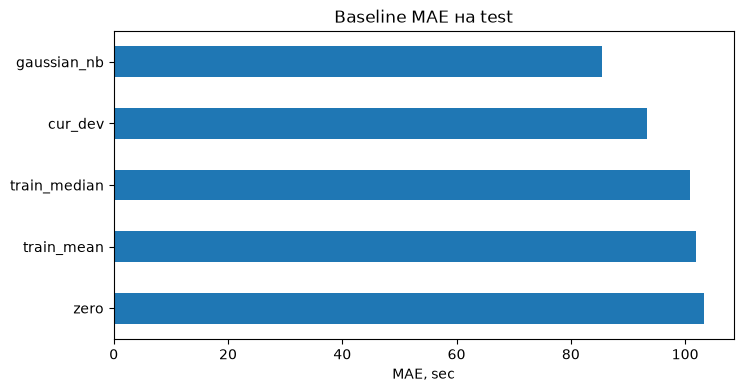

In [9]:
bl_metrics.sort_values(ascending=False).plot.barh(figsize=(8, 4))
plt.title('Baseline MAE на test')
plt.xlabel('MAE, sec')
plt.show()


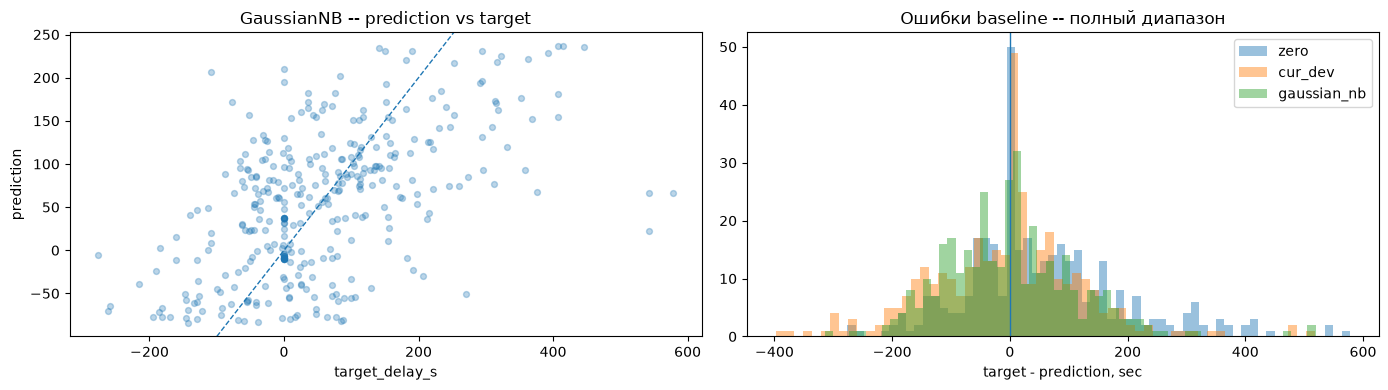

In [10]:
bl_fig, bl_axes = plt.subplots(1, 2, figsize=(14, 4))

bl_axes[0].scatter(
    bl_test.target_delay_s,
    bl_test_predictions.gaussian_nb,
    alpha=.3,
    s=18
)
bl_axes[0].axline((0, 0), slope=1, linestyle='--', linewidth=1)
bl_axes[0].set_title('GaussianNB -- prediction vs target')
bl_axes[0].set_xlabel('target_delay_s')
bl_axes[0].set_ylabel('prediction')

for name in ['zero', 'cur_dev', 'gaussian_nb']:
    bl_axes[1].hist(
        bl_test.target_delay_s - bl_test_predictions[name],
        bins=60,
        alpha=.45,
        label=name
    )
bl_axes[1].axvline(0, linewidth=1)
bl_axes[1].set_title('Ошибки baseline -- полный диапазон')
bl_axes[1].set_xlabel('target - prediction, sec')
bl_axes[1].legend()

plt.tight_layout()


На real test константы дают MAE около 101--103 секунд, `cur_dev_s` -- 93.36 секунды, GaussianNB -- 85.53 секунды.

Для такого простого baseline результат NB заметно лучше ожидаемого. Значит, грубое разделение на `early / ontime / late` уже ловит часть нелинейности между текущим отклонением и будущей задержкой. Это аргумент позже проверить двухэтапную схему `class -> regression` или mixture of experts, но финальную модель все равно оцениваю по MAE в секундах.

## 5. Learning curve GaussianNB

Для baseline смотрю, насыщается ли он по мере роста train. Test оставляю фиксированным, train беру стратифицированными долями по классам.

In [11]:
def bl_stratified_fraction(data, fraction):
    return (
        data.groupby('target_class', group_keys=False)
        .sample(frac=fraction, random_state=BL_SEED)
        .sort_index()
    )


In [12]:
bl_fractions = [.1, .25, .5, .75, 1.0]
bl_curve_rows = []

for bl_fraction in bl_fractions:
    bl_part = bl_stratified_fraction(bl_train, bl_fraction)
    bl_part_x = bl_make_nb_features(bl_part)

    bl_part_scaler = StandardScaler()
    bl_part_x_scaled = bl_part_scaler.fit_transform(bl_part_x)
    bl_test_x_scaled = bl_part_scaler.transform(bl_x_test)

    bl_part_nb = GaussianNB()
    bl_part_nb.fit(bl_part_x_scaled, bl_part.target_class)

    bl_part_delay = bl_part.groupby('target_class').target_delay_s.mean().reindex(bl_part_nb.classes_)
    bl_part_train_pred = bl_part_nb.predict_proba(bl_part_x_scaled) @ bl_part_delay.to_numpy()
    bl_part_test_pred = bl_part_nb.predict_proba(bl_test_x_scaled) @ bl_part_delay.to_numpy()

    bl_curve_rows.append({
        'train_size': len(bl_part),
        'train_mae': mean_absolute_error(bl_part.target_delay_s, bl_part_train_pred),
        'test_mae': mean_absolute_error(bl_test.target_delay_s, bl_part_test_pred)
    })

bl_learning_curve = pd.DataFrame(bl_curve_rows)
bl_learning_curve


,train_size,train_mae,test_mae
0,444,87.746879,86.819228
1,1109,88.419631,86.250348
2,2217,87.400837,86.158999
3,3325,85.291614,85.739461
4,4434,84.932882,85.525081


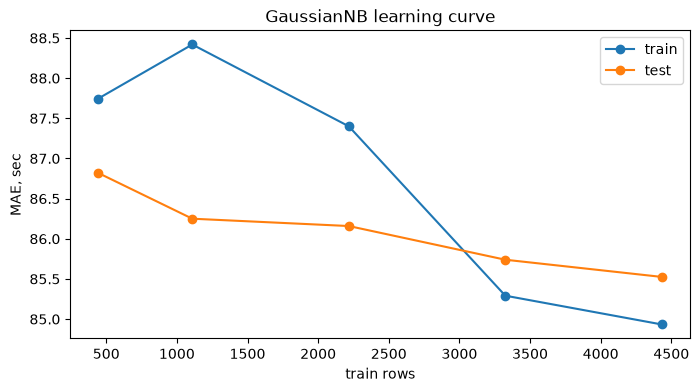

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(bl_learning_curve.train_size, bl_learning_curve.train_mae, marker='o', label='train')
plt.plot(bl_learning_curve.train_size, bl_learning_curve.test_mae, marker='o', label='test')
plt.title('GaussianNB learning curve')
plt.xlabel('train rows')
plt.ylabel('MAE, sec')
plt.legend()
plt.show()


Learning curve почти стабилизируется: test MAE снижается примерно с 86.8 до 85.5 секунды при росте train с 10% до 100%. То есть для самого GaussianNB дальнейший прирост данных уже не решит проблему -- нужен более выразительный класс моделей и признаки из `02`.

## 6. Submission-файлы

Все файлы сохраняю в `../submissions/baseline`. Формат и порядок `sample_id` беру из официального шаблона.

In [14]:
bl_output_dir = Path('../submissions/baseline')
bl_output_dir.mkdir(parents=True, exist_ok=True)

bl_validate_predictions = {
    'baseline_zero.csv': np.zeros(len(bl_validate)),
    'baseline_train_mean.csv': np.full(len(bl_validate), bl_train_mean),
    'baseline_train_median.csv': np.full(len(bl_validate), bl_train_median),
    'baseline_cur_dev.csv': bl_validate.cur_dev_s.to_numpy(),
    'baseline_gaussian_nb.csv': bl_validate_nb
}


In [15]:
for bl_filename, bl_prediction in bl_validate_predictions.items():
    bl_pred_map = pd.Series(bl_prediction, index=bl_validate.sample_id)
    bl_submission = bl_submission_template.copy()
    bl_submission['prediction'] = bl_submission.sample_id.map(bl_pred_map)
    bl_submission.to_csv(bl_output_dir / bl_filename, sep=';', index=False)

sorted(path.name for path in bl_output_dir.glob('*.csv'))


['baseline_cur_dev.csv',
 'baseline_gaussian_nb.csv',
 'baseline_train_mean.csv',
 'baseline_train_median.csv',
 'baseline_zero.csv']

In [16]:
pd.DataFrame({
    'file': list(bl_validate_predictions),
    'prediction_mean': [np.mean(x) for x in bl_validate_predictions.values()],
    'prediction_std': [np.std(x) for x in bl_validate_predictions.values()]
})


,file,prediction_mean,prediction_std
0,baseline_zero.csv,0.000000,0.000000e+00
1,baseline_train_mean.csv,48.889716,7.105427e-15
2,baseline_train_median.csv,24.000000,0.000000e+00
3,baseline_cur_dev.csv,59.768212,1.542327e+02
4,baseline_gaussian_nb.csv,55.782998,8.935101e+01


Дальше константы нужны только как контроль. Первый полноценный шаг -- бустинг на признаках из `02`, причем отдельно сравнить предсказание самого `target_delay_s` и residual `target_delay_s - cur_dev_s`.